I just got back from Ireland - was on vacation for a week. I was standing in line at the Guinness Storehouse for a tour and there was this person in front of us with a super thick lens over one eye and not as thick over the other in his glasses. I thought, wow, he must have bad aniseikonia (perception of the magnification disparity that comes with difference in spectacle lens power). This optical phenomenon is only really present for glasses and not for contact lenses (because the effect is a product of the vertex distance - the distance between the corrective lens and the eye; that I have general knowledge about but couldn’t explain beyond that), but it is highly relevant to amblyopia because we are only able to correct anisometropia with glasses in kids because they won’t wear contact lenses and refractive surgery is considered relatively fringe stuff right now. I recalled that there is a group who hypothesizes that this mismatch in image size serves as a barrier to recovery - this is to say, the universal treatment for anisometropic amblyopia (glasses) introduces a new interocular disparity (a spatial one in the form of image size), and this could compromise recovery. Counter therapeutic contributions of aniseikonia probably go unrecognized clinically because the size of the disparity is higher with higher degrees of anisometropia, so we just assume the tampered recovery in those more severe cases is due to the stronger amblyogenic driver (i.e. greater anisometropia).

I looked through the literature quickly and found that the group that is actively looking at this is in New Zealand. Here are some of their recent publications: 

https://pubmed.ncbi.nlm.nih.gov/35478070/
https://pubmed.ncbi.nlm.nih.gov/34278210/
https://pubmed.ncbi.nlm.nih.gov/30791133/

Why am I bringing this up to you? 
Well, I thought it would be super easy to apply your model to help answer this question. The experiment would be the same as what you previously did in giving the model amblyopia with a change in interocular blur, but when the “fix" is put in place, compare the fix alone with the fix plus aniseikonia (a difference in image size). Experiment 1 would be looking at this relationship as a function of the blur/refractive correction and image disparity. Experiment 2 would be to also add on subsequent optimal dichoptic therapy (contrast disparity plus mask) and ask how aniseikonia may mitigate treatment response to dichoptic therapy.

Why would knowing this be important?
The Luminopia platform could be easily modified to adjust the interocular image size to account for aniseikonia. This experiment would clue us into whether this would be worthwhile. Yes, this would represent a third paper! If you have the appetite for it.

In [1]:
from pylab import *
from input_environment_defs import *

Splikes version  0.1.5
Plasticnet version  0.1.14


In [2]:
def get_input_patch_examples(Lnorm_fname,Rnorm_fname,rf_size=19,noise=[0.1,0.1],contrast=[1,1]):
    
    eta=2e-6

    

    number_of_neurons=1,        

    pre1=pn.neurons.natural_images(Lnorm_fname,
                                   rf_size=rf_size,verbose=False)

    pre2=pn.neurons.natural_images(Rnorm_fname,rf_size=rf_size,
                                other_channel=pre1,
                                verbose=False)

    
    sigma=noise[0]
    if contrast[0]!=1:
        pre1+=pn.neurons.process.scale_shift(contrast,0)
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)

    sigma=noise[1]
    if contrast[1]!=1:
        pre2+=pn.neurons.process.scale_shift(contrast,0)
    pre2+=pn.neurons.process.add_noise_normal(0,sigma)
    
    pre=pre1+pre2

    sim=pn.simulation(100)
    sim.monitor(pre,['output'],1)
    sim.monitor(pre1,['pattern','p','c','r'],1)
    sim.monitor(pre2,['pattern','p','c','r'],1)

    pn.run_sim(sim,[pre],[],display_hash=False,print_time=False)

    m=sim.monitors['output']
    t,X=m.arrays()
    
    X=X[1:,:]
    
    
    return sim,X


Original images made with 2023-06-02 - Images for Amblyopia.py  saved to 'asdf/bbsk081604_all_scale2.asdf'

Base Image File: asdf/bbsk081604_all_scale2.asdf


Text(0.5, 0.98, 'asdf/bbsk081604_all_scale2.asdf')

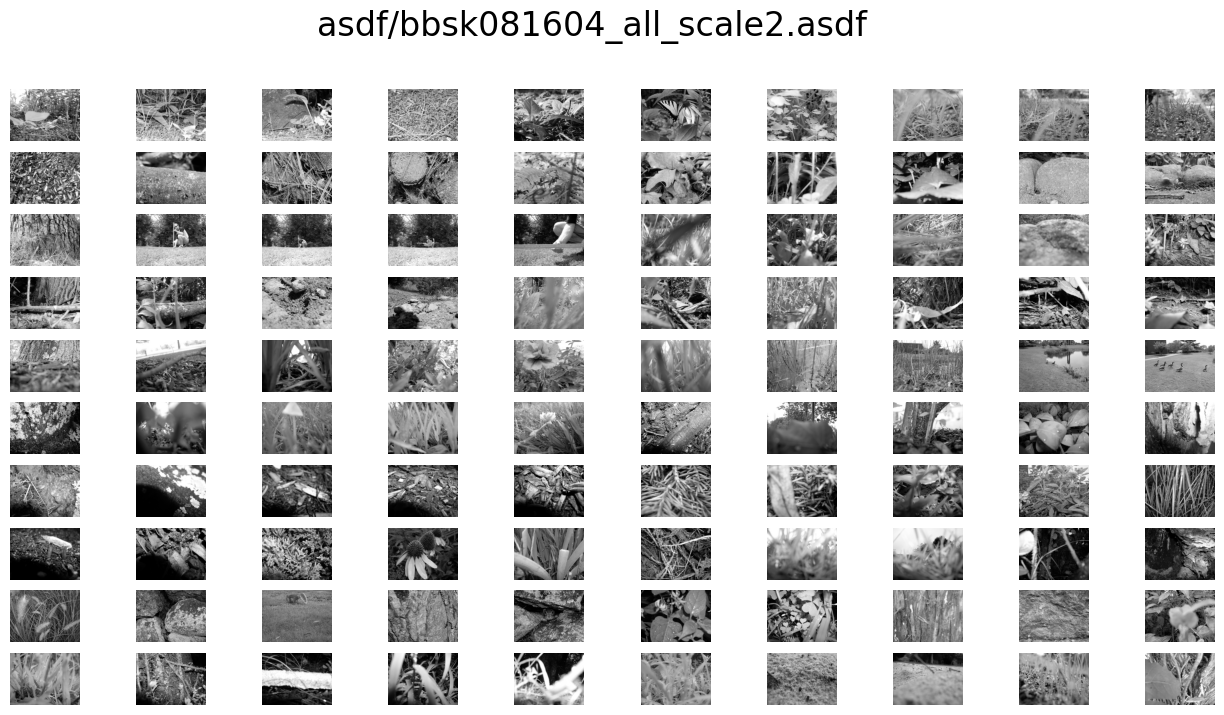

In [3]:
base_image_file=asdf_fname='asdf/bbsk081604_all_scale2.asdf'
print("Base Image File:",base_image_file)

image_data=pi5.asdf_load_images(base_image_file)
images=[arr.astype(float)*image_data['im_scale_shift'][0]+
        image_data['im_scale_shift'][1] for arr in image_data['im']]

del image_data
figure(figsize=(16,8))
for i in range(100):
    subplot(10,10,i+1)
    im=images[i]
    imshow(im,cmap=plt.cm.gray)
    axis('off')
    
suptitle(base_image_file)

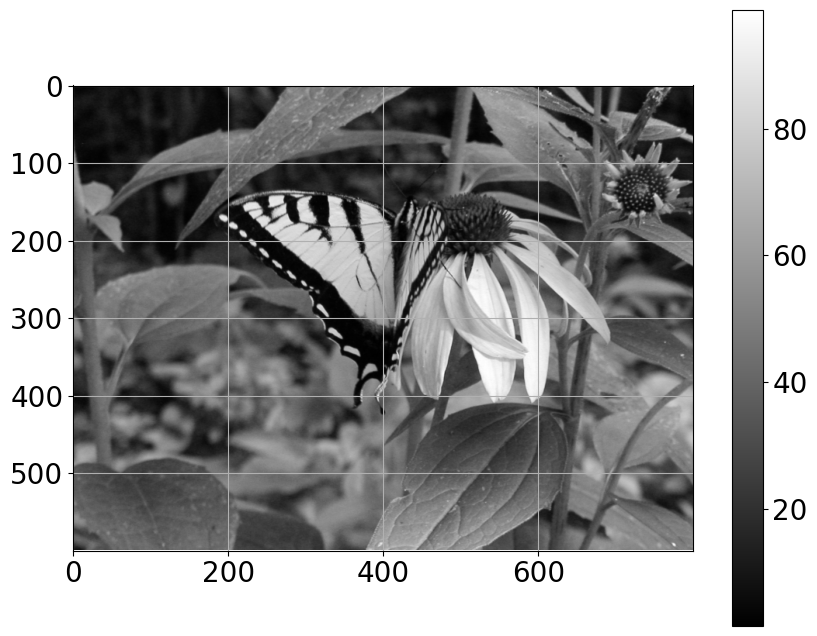

In [4]:
im=images[5]
imshow(im,cmap=cm.gray)
colorbar()

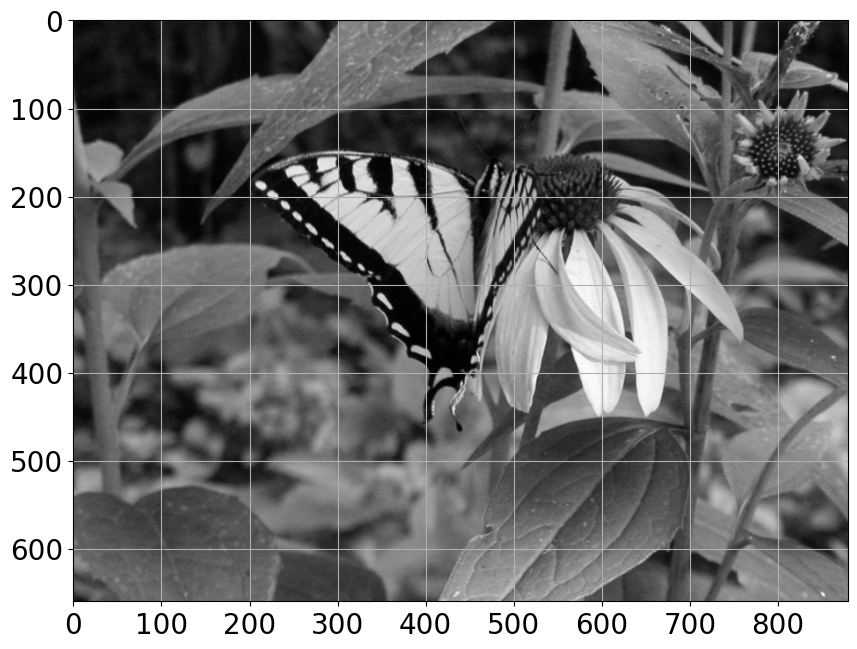

In [5]:
from scipy.ndimage import zoom
scale = 1.1
resized = zoom(im, zoom=scale, order=3)

imshow(resized,cmap=cm.gray)

In [6]:
patches = np.lib.stride_tricks.sliding_window_view(im, (19, 19)).reshape(-1, 19, 19)
patches.shape

(455124, 19, 19)

In [7]:
patches[0].shape

(19, 19)

Using cache_images/cache_images_66a66c3735b3f9a2f3b3b0c5cf4fc5c0.asdf from cache.Using cache_images/cache_images_66a66c3735b3f9a2f3b3b0c5cf4fc5c0.asdf from cache.

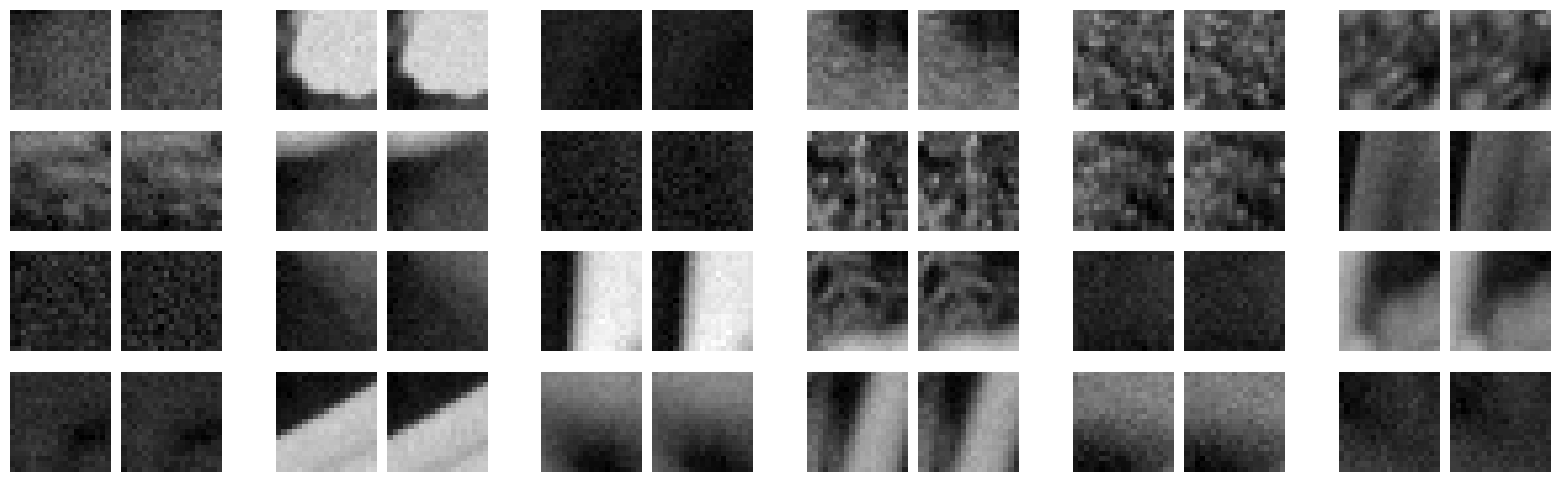

In [8]:
Lnorm_fname=pi5.filtered_images(base_image_file,
                            {'type':'norm'},
                            verbose=True)
Rnorm_fname=pi5.filtered_images(base_image_file,
                            {'type':'norm'},
                            verbose=True)


sim,X=get_input_patch_examples(Lnorm_fname,Rnorm_fname)
ims=inputs_to_images(X,buffer=2)
figure(figsize=(20,6))
for i in range(24):
    im=ims[i]
    subplot(4,6,i+1)
    imshow(im,cmap=plt.cm.gray)
    axis('off')
 

In [9]:
X.shape

(101, 722)

Using cache_images/cache_images_b499590c4b38a1a355bf93d0c6ff3a9f.asdf from cache.Using cache_images/cache_images_66a66c3735b3f9a2f3b3b0c5cf4fc5c0.asdf from cache.

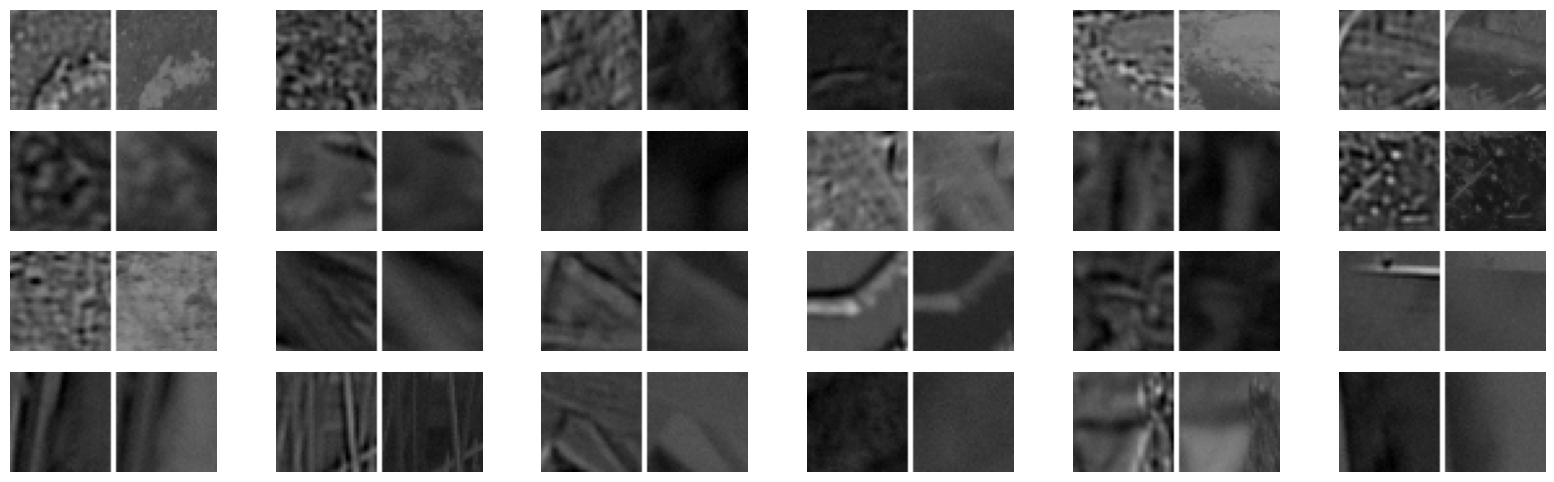

In [10]:
Lnorm_fname=pi5.filtered_images(base_image_file,
                            {'type':'blur','size':1},
                            {'type':'norm'},
                            verbose=True)
Rnorm_fname=pi5.filtered_images(base_image_file,
                            {'type':'norm'},
                            verbose=True)
rf_size=39
sim,X=get_input_patch_examples(Lnorm_fname,Rnorm_fname,rf_size=rf_size)
ims=inputs_to_images(X,buffer=2)
figure(figsize=(20,6))
for i in range(24):
    im=ims[i]
    subplot(4,6,i+1)
    imshow(im,cmap=plt.cm.gray)
    axis('off')



In [11]:
sim.monitors

{'output': <plasticnet.plasticnet.monitor at 0x12723ac40>,
 'pattern': <plasticnet.plasticnet.monitor at 0x1371ed440>,
 'p': <plasticnet.plasticnet.monitor at 0x1371ed2c0>,
 'c': <plasticnet.plasticnet.monitor at 0x1371eed40>,
 'r': <plasticnet.plasticnet.monitor at 0x1371ee840>,
 'pattern_1': <plasticnet.plasticnet.monitor at 0x1371ef040>,
 'p_1': <plasticnet.plasticnet.monitor at 0x1371eebc0>,
 'c_1': <plasticnet.plasticnet.monitor at 0x1371eefc0>,
 'r_1': <plasticnet.plasticnet.monitor at 0x1371eedc0>}

In [12]:
r,c,p=sim.monitors['r'].array(),sim.monitors['c'].array(),sim.monitors['p'].array()

In [13]:
X.shape

(101, 3042)

In [14]:
idx=3
x1=X[idx-1,:rf_size*rf_size].reshape(rf_size,rf_size)
x2=X[idx-1,rf_size*rf_size:].reshape(rf_size,rf_size)

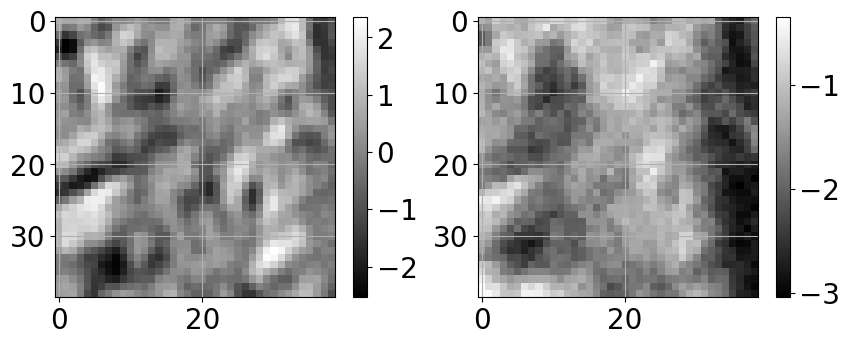

In [15]:
subplot(2,2,1)
imshow(x1,cmap=cm.gray)
colorbar()
subplot(2,2,2)
imshow(x2,cmap=cm.gray)
colorbar()

Using cache_images/cache_images_ba63c51e208a95ef81b4eebcc3767cfd.asdf from cache.

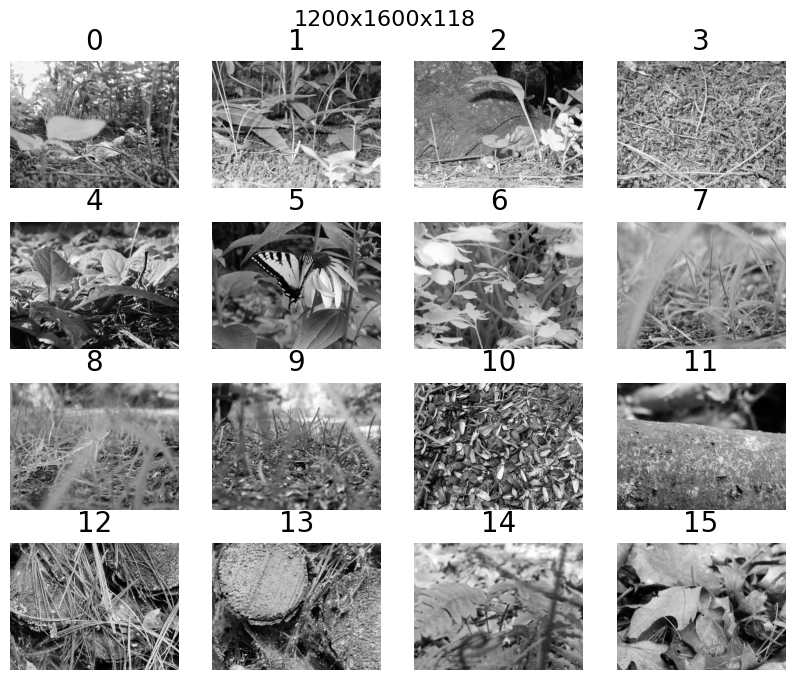

In [17]:
Lnorm_fname=pi5.filtered_images(base_image_file,
                                {'type':'zoom','scale':2},
                            {'type':'norm'},
                            verbose=True)


pi5.view(Lnorm_fname,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])